In [1]:
import sys
sys.executable
print(sys.executable)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from collections import defaultdict
import matplotlib.ticker as ticker
import glob
import os
import pickle
import sys
import re
import ast
import uproot
import awkward as ak
sys.path.append("/scratch/halmazan//WCTE/WCTECoincidence_Analysis/Complete_analysis")
from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [10, 8]
rcParams['font.size'] = 22

/scratch/halmazan/conda/envs/hk_software/bin/python


In [6]:
input_path = '/data/halmazan/WCTE/MC/'
file = 'wcte_ambe_mc_digidata_NEW_0.root'

path = os.path.join(input_path, file)

# Open file
f = uproot.open(path)
print("Keys in file:", f.keys())


Keys in file: ['WCTEReadoutWindows;1', 'TTrueInfo;1']


In [7]:
# Get tree
t = f["TTrueInfo"]
print(t)  # shows entries, branches

# List branches
print("Branches:", t.keys())

<TTree 'TTrueInfo' (40 branches) at 0x7f5700669cf0>
Branches: ['event_number', 'n_overlay', 'nx', 'x', 'ny', 'y', 'nz', 'z', 'ndx', 'dx', 'ndy', 'dy', 'ndz', 'dz', 'nhit_from_prompt', 'hit_from_prompt', 'nhit_from_capture', 'hit_from_capture', 'nsource_event_idx', 'source_event_idx', 'ncapture_t', 'capture_t', 'nrelative_capture_t', 'relative_capture_t', 'nprompt_time_withcapture', 'prompt_time_withcapture', 'nprompt_time', 'prompt_time', 'ncapture_x', 'capture_x', 'ncapture_y', 'capture_y', 'ncapture_z', 'capture_z', 'ncapture_nucleus', 'capture_nucleus', 'ncapture_ngamma', 'capture_ngamma', 'ncapture_total_gammaE', 'capture_total_gammaE']


In [9]:
t["event_number"].array(library="np")

array([    0,     1,     2, ..., 99997, 99998, 99999],
      shape=(100000,), dtype=int32)

In [3]:
input_path = '/data/halmazan/WCTE/data/2384/v0_5/'
file = 'WCTE_offline_R2384S0P0.root'

path = os.path.join(input_path, file)

# Open file
f = uproot.open(path)
print("Keys in file:", f.keys())

# Get tree
t = f["WCTEReadoutWindows"]
print(t)  # shows entries, branches

# List branches
print("Branches:", t.keys())

Keys in file: ['WCTEReadoutWindows;4', 'WCTEReadoutWindows;3']
<TTree 'WCTEReadoutWindows' (37 branches) at 0x7f7a4058eda0>
Branches: ['window_time', 'start_counter', 'run_id', 'sub_run_id', 'spill_counter', 'event_number', 'readout_number', 'trigger_types', 'trigger_times', 'led_gains', 'led_dacsettings', 'led_ids', 'led_card_ids', 'led_slot_numbers', 'led_event_types', 'led_types', 'led_sequence_numbers', 'led_counters', 'hit_mpmt_card_ids', 'hit_pmt_channel_ids', 'hit_mpmt_slot_ids', 'hit_pmt_position_ids', 'hit_pmt_charges', 'hit_pmt_times', 'pmt_waveform_mpmt_card_ids', 'pmt_waveform_pmt_channel_ids', 'pmt_waveform_mpmt_slot_ids', 'pmt_waveform_pmt_position_ids', 'pmt_waveform_times', 'pmt_waveforms', 'beamline_pmt_qdc_charges', 'beamline_pmt_tdc_times', 'beamline_pmt_qdc_ids', 'beamline_pmt_tdc_ids', 'window_data_quality', 'hit_pmt_calibrated_times', 'hit_pmt_readout_mask']


In [4]:
# Read a few branches as arrays
branches = [
    "event_number", "n_overlay",
    "x","y","z","dx","dy","dz",
    "hit_from_prompt","hit_from_capture",
    "source_event_idx",
    "capture_t","relative_capture_t",
    "prompt_time_withcapture","prompt_time",
    "capture_x","capture_y","capture_z",
    "capture_nucleus","capture_ngamma","capture_total_gammaE",
]
arrs = t.arrays(branches, library="ak")

# Example: print first 5 entries of a couple fields
print("event_number[:5] =", ak.to_list(arrs["event_number"][:5]))
print("capture_t[:5]    =", ak.to_list(arrs["capture_t"][:5]))
print("prompt_time[:5]    =", ak.to_list(arrs["prompt_time"][:5]))


event_number[:5] = [0, 1, 2, 3, 4]
capture_t[:5]    = [[5474.890224132454, 83437.38224694831, 9824.60509413085, 1819.101355627412, 125087.77348719444, 14698.95113519649, 245803.37450554944, 19377.518131258897, 75719.08679655031, 216301.7892010333], [49992.97562057362, 45736.77308801212, 64782.780141947325, 66837.09300458338, 258193.6192832135, 29167.852847612463, 253564.14420853672, 233129.6676493222, 117173.75680437102, 87911.31968167704, 235773.06100443797, 145794.80841507227], [31641.287273318274, 68477.01162354182, 47161.44063497707, 81138.6069617956, 231938.41848020535, 181335.8780713277, 229482.16277949465, 133195.43298003543, 55728.1919008696, 124830.47707185755], [11896.440444585867, 113318.79571204586, 70510.1674552965, 235013.01751407655, 208300.49145234935, 168800.42383914161, 77692.37146996567], [145704.53809558088, 267718.2333530248, 234061.99248282518, 133858.78643023688, 170004.38272521785, 189786.04584885435, 151716.51296550967, 115138.5168395224, 187698.6920659477]]
pr

In [5]:
path = "/data/halmazan/WCTE/MC/wcte_ambe_mc_data_0.root"
t = uproot.open(path)["TTrueInfo"]

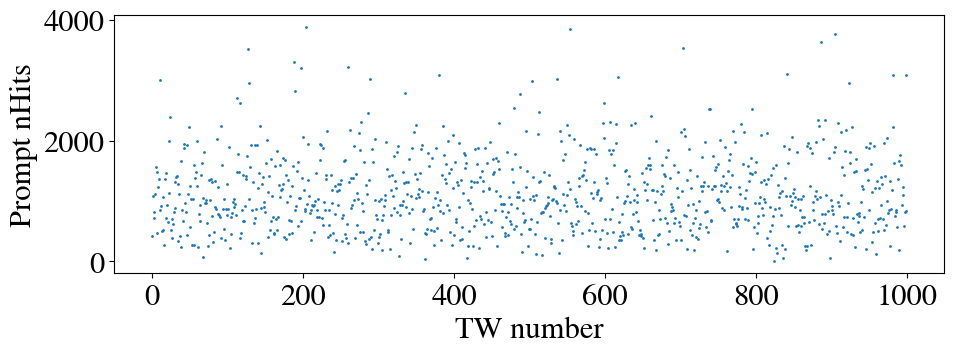

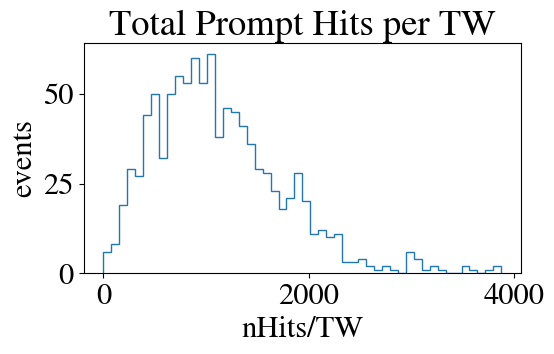

In [6]:
event = t["event_number"].array(library="np")
hitp  = t["hit_from_prompt"].array(library="ak")   # jagged

n_prompt_hits = ak.to_numpy(ak.sum(hitp == 1, axis=1))
n_prompt_hits = ak.to_numpy(n_prompt_hits) 

order = np.argsort(event)
plt.figure(figsize=(10,4))
plt.plot(event[order], n_prompt_hits[order], ".", markersize=2)
plt.xlabel("TW number")
plt.ylabel("Prompt nHits")
plt.tight_layout()
plt.show()

y = n_prompt_hits  # this is already per-event

# Option 1: automatic binning
plt.figure(figsize=(6,4))
plt.hist(y, bins=50, histtype="step")
plt.xlabel("nHits/TW")
plt.ylabel("events")
plt.title("Total Prompt Hits per TW")
plt.tight_layout()
plt.show()

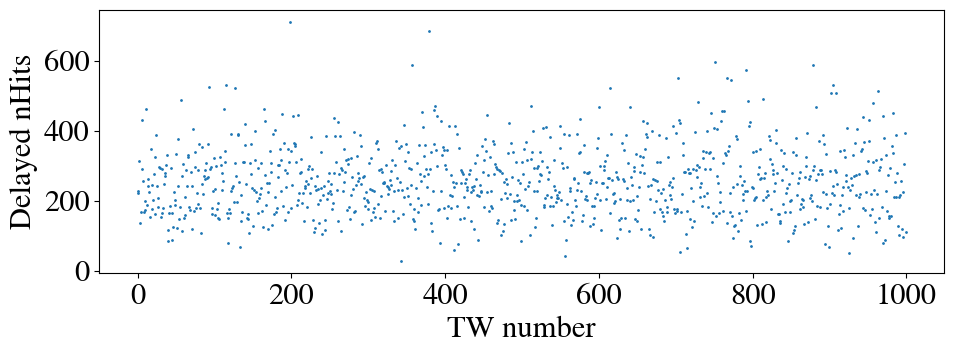

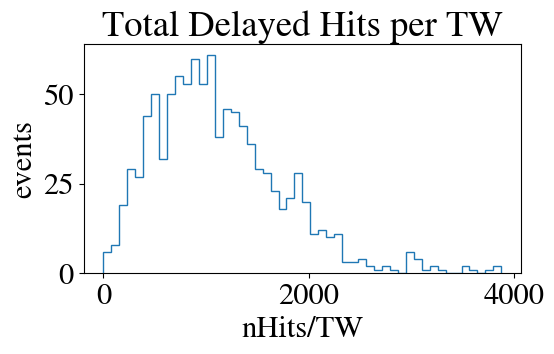

In [7]:
event = t["event_number"].array(library="np")
hitd  = t["hit_from_capture"].array(library="ak")   # jagged

n_delayed_hits = ak.to_numpy(ak.sum(hitd == 1, axis=1))
n_delayed_hits = ak.to_numpy(n_delayed_hits)

order = np.argsort(event)
plt.figure(figsize=(10,4))
plt.plot(event[order], n_delayed_hits[order], ".", markersize=2)
plt.xlabel("TW number")
plt.ylabel("Delayed nHits")
plt.tight_layout()
plt.show()

y = n_prompt_hits  # this is already per-event

# Option 1: automatic binning
plt.figure(figsize=(6,4))
plt.hist(y, bins=50, histtype="step")
plt.xlabel("nHits/TW")
plt.ylabel("events")
plt.title("Total Delayed Hits per TW")
plt.tight_layout()
plt.show()


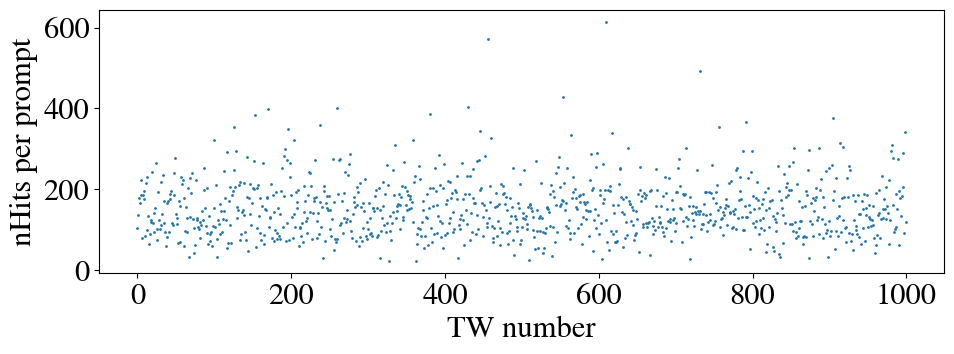

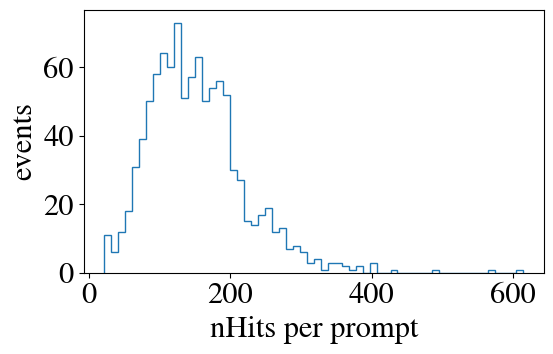

In [8]:
event = t["event_number"].array(library="np")
prompt_time = t["prompt_time"].array(library="ak")        # jagged: prompts per event
hitp = t["hit_from_prompt"].array(library="ak")           # jagged: hits per event (0/1)

# 1) number of prompts per event (length of prompt_time list)
n_prompts = ak.num(prompt_time, axis=1)                   # per-event counts
n_prompts = ak.to_numpy(n_prompts)

# 2) number of prompt hits per event (count only 1s)
n_prompt_hits = ak.sum(hitp == 1, axis=1)
n_prompt_hits = ak.to_numpy(n_prompt_hits)

# 3) prompt hits per prompt (handle 0-prompt events safely)
hits_per_prompt = np.divide(
    n_prompt_hits, n_prompts,
    out=np.full_like(n_prompt_hits, np.nan, dtype=float),
    where=(n_prompts > 0)
)

# --- Plots ---
order = np.argsort(event)

plt.figure(figsize=(10,4))
plt.plot(event[order], hits_per_prompt[order], ".", markersize=2)
plt.xlabel("TW number")
plt.ylabel("nHits per prompt")
plt.tight_layout()
plt.show()

# Y-projection of hits-per-prompt
plt.figure(figsize=(6,4))
plt.hist(hits_per_prompt[np.isfinite(hits_per_prompt)], bins=60, histtype="step")
plt.xlabel("nHits per prompt")
plt.ylabel("events")
plt.tight_layout()
plt.show()

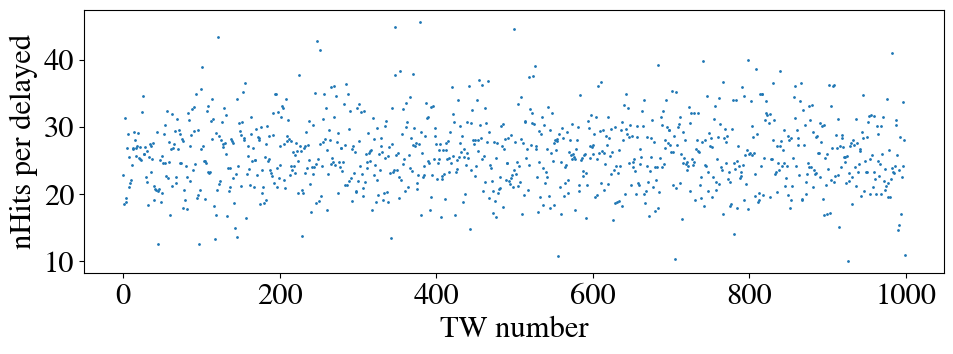

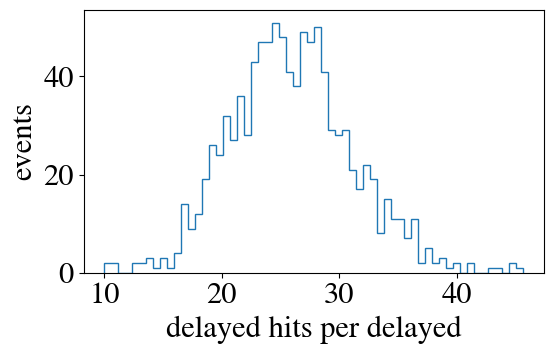

In [9]:
event = t["event_number"].array(library="np")
delayed_time = t["capture_t"].array(library="ak")        # jagged: prompts per event
hitd = t["hit_from_capture"].array(library="ak")           # jagged: hits per event (0/1)

# 1) number of prompts per event (length of prompt_time list)
n_delayed = ak.num(delayed_time, axis=1)                   # per-event counts
n_delayed = ak.to_numpy(n_delayed)

# 2) number of prompt hits per event (count only 1s)
n_delayed_hits = ak.sum(hitd == 1, axis=1)
n_delayed_hits = ak.to_numpy(n_delayed_hits)

# 3) prompt hits per prompt (handle 0-prompt events safely)
hits_per_delayed = np.divide(
    n_delayed_hits, n_delayed,
    out=np.full_like(n_delayed_hits, np.nan, dtype=float),
    where=(n_prompts > 0)
)

# --- Plots ---
order = np.argsort(event)

plt.figure(figsize=(10,4))
plt.plot(event[order], hits_per_delayed[order], ".", markersize=2)
plt.xlabel("TW number")
plt.ylabel("nHits per delayed")
plt.tight_layout()
plt.show()

# Y-projection of hits-per-prompt
plt.figure(figsize=(6,4))
plt.hist(hits_per_delayed[np.isfinite(hits_per_delayed)], bins=60, histtype="step")
plt.xlabel("delayed hits per delayed")
plt.ylabel("events")
plt.tight_layout()
plt.show()